In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator # verileri alıp değişik yöntemlerle artırımı yapılması için
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D , Flatten ,Dense , Dropout , Input
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K # grad-cam gradyan hesaplamaları için 

In [57]:
dosya_yol='/Users/sametkarayel/Desktop/sitma_tespiti/cell_images'

parasitized_dir = os.path.join(dosya_yol, 'Parasitized')
uninfected_dir = os.path.join(dosya_yol, 'Uninfected')

p_count=len(os.listdir(parasitized_dir))# veri sayılarımıza bakıyoruz
u_count=len(os.listdir(uninfected_dir))
print(p_count)
print(u_count)


13780
13780


In [58]:
sample_p_name = os.listdir(parasitized_dir)[0] # burda klasörleri listeye çevirip belirtilen index deki görselleri alıyoruz 
sample_u_name = os.listdir(uninfected_dir)[2]

In [59]:
img_p = cv2.imread(os.path.join(parasitized_dir, sample_p_name)) # burda iki etiketden de iki görsele bi bakalım dedik 
img_u = cv2.imread(os.path.join(uninfected_dir, sample_u_name))

(-0.5, 123.5, 114.5, -0.5)

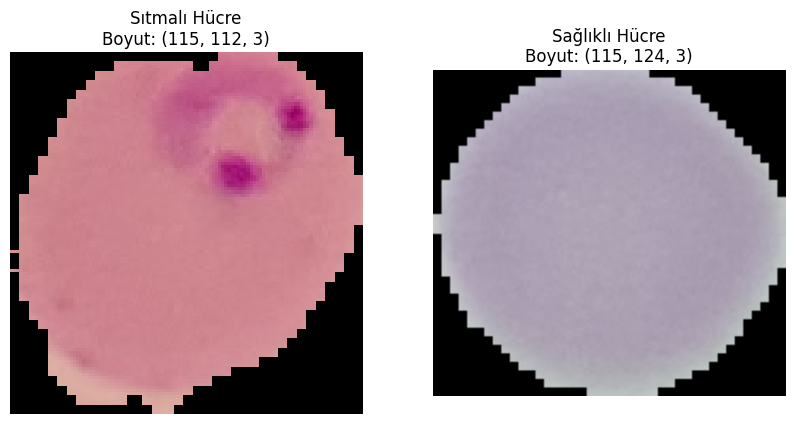

In [60]:
plt.figure(figsize=(10, 5)) 
plt.subplot(1, 2, 1) 
plt.imshow(cv2.cvtColor(img_p, cv2.COLOR_BGR2RGB))
plt.title(f"Sıtmalı Hücre\nBoyut: {img_p.shape}") 
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_u, cv2.COLOR_BGR2RGB))
plt.title(f"Sağlıklı Hücre\nBoyut: {img_u.shape}")
plt.axis('off')

In [61]:
IMG_HEIGHT, IMG_WIDTH = 128, 128
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,           # görsel veriler üzerinde normalizasyon yapıyoruz 
    rotation_range=20,        # resmi sağ sol 20 derece arası döndüryoruz
    width_shift_range=0.1,    # görseli sağ sol 0.1 kaydırmak için kullanıyoruz maksadımız hücrenin biraz sağ solda kalmış olma durumunda modelin ilk defa görmüş olmaması
    height_shift_range=0.1,   # aynısının aşşağı yukarı olanı
    shear_range=0.1,          # Görüntüyü rastgele bükerek (yamultarak) perspektif kazandırır.
    zoom_range=0.1,           # hücreye 0.1 uzaklaştırarak veya yakınlaştırarak 
    horizontal_flip=True,     # modelin gördüğü veri sayısını elimizden geldigince arttırmak için horizontal yani yatay olarak yansımasını alıyoruz
    fill_mode='nearest',      # kaydırma/döndürme sonrası oluşan boşlukları en yakın piksellerle doldurur
    validation_split=0.2      # burda veri setini yüzdesel olarak 80 e 20 ayırıyoruz
) 
    

In [62]:
train_generator = datagen.flow_from_directory(
    dosya_yol,                
    target_size=(IMG_HEIGHT, IMG_WIDTH), #tüm resimleri 128 e 128 yapar 
    batch_size=BATCH_SIZE,    # verileri 32 şerli olarak eğitime gönderiyoruz
    class_mode='binary',      # modelin etiketleri 2 li olarak kodlamasını söylüyoruz
    subset='training',        # Burda 'training' (%80) kısmını kullanmasını söylüyoruz
    shuffle=True              # verileri karıştırıyoruz çünkü karıştırmazsak klasör etiketi üzerinde kalır böyle olursa model ezber olur
)
val_generator = datagen.flow_from_directory(
    dosya_yol,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',      # Burda da aynı şekil test verisini alıyoruz
    shuffle=False             # test ederken sonucu doğru değerlendirsin etiketi karışmasın diye karıştırmıyoruz 
)

Found 22047 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.


In [63]:
model = tf.keras.models.Sequential([
    
    # modelin eğitim katmanlarında aranan özellik sayısını çıkış katmanına doğru arttırıyoruz bunun sebebi basit detaylardan karmaşık detaylara doğru tespit etmek
    tf.keras.layers.Input(shape=(128,128,3)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2), # görüntüyü enine boyuna yarısına indiriyoruz yüzde 25ine düşüyor boyutu böylece veri eğitim sürecinde daha az yük oluyor

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),# model 128 özellik arayacak bu özellikleri 3x3 piksellik alanlara bakarak arayacak, relu parametresi ise negatif görülenleri engelleyerek pozitif sinyalleri sonraki katmana gönderecek
    tf.keras.layers.MaxPooling2D(2, 2),


    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', name='son_conv_katmani'),# model 128 özellik arayacak bu özellikleri 3x3 piksellik alanlara bakarak arayacak
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(), # 2 boyutlu veriyi tek boyuta yani vektöre çevirir
    tf.keras.layers.Dense(128, activation='relu'), #128 nöronlu gizli katman
    tf.keras.layers.Dropout(0.5), # modelin ezberlemesini engellemek için her egitimde yarısını kapatıyoruz nöronların 
    
    tf.keras.layers.Dense(1, activation='sigmoid') # çıkış katmanını inşa ettik 2 seçenek arasında karar vereceği için sigmoid kullandık
])

In [67]:
model.compile(
    optimizer=Adam(learning_rate=0.0001), # ağırlıklarını güncellerken adam optimizeri kullanıyoz
    loss='binary_crossentropy', # modelin loss değerini ölçen mekanizmayı seçiyoruz iki sınıf oldugu için binary
    metrics=['accuracy'] # bu da aynı şekilde doğruluk değerini bize gösterecek
)
model.summary() # bunla modelin rönteginin çıkartıyoruz katmanlar ve önemli parametre değerleri gibi

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ son_conv_katmani (Conv2D)       │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [69]:
early_stop = tf.keras.callbacks.EarlyStopping( #model gelişmeyi durdurdugunda erkendenden durmasını istiyorum
    monitor='val_loss', # durdurmak için gerekli parametreyi giriyoruz 
    patience=5, # modele 5 epoch boyunca sabret diyoruz 5 epoch boyunca iyileşme göstermezse durdurur
    restore_best_weights=True #model diyelim 5 epoch val_loss un arttıgı senaryoda son ulaştıgı katman ağırlıkları biraz daha ezberlemiş olacak o yüzden en son gördüğü verimli ağırlıklara dönmesini sağlıyoruz bu parametre ile
)

# modelin katman bilgi ve parametrelerini girdik şimdi eğitelim
history = model.fit( # history değişkeni modelin her epoch bittiginde verileri alır bu sayede early_stop umuz devreye girer bir de eğitim sonrası eğitim sürecini grafik haline getirmek için kullanıyoruz
    train_generator,                    
    epochs=20,                          
    validation_data=val_generator,        
    validation_steps=val_generator.samples // BATCH_SIZE, 
    callbacks=[early_stop]               # az önce tanımladığımız erken durdurma kuralı
)

Epoch 1/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.6502 - loss: 1.5422 - val_accuracy: 0.4998 - val_loss: 7.1652
Epoch 2/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 59s 85ms/step - accuracy: 0.6132 - loss: 1.5825 - val_accuracy: 0.8130 - val_loss: 0.5211
Epoch 3/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 56s 82ms/step - accuracy: 0.6318 - loss: 1.9825 - val_accuracy: 0.7900 - val_loss: 0.5996
Epoch 4/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 56s 82ms/step - accuracy: 0.7615 - loss: 0.8589 - val_accuracy: 0.8919 - val_loss: 0.3583
Epoch 5/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 56s 81ms/step - accuracy: 0.8746 - loss: 0.3941 - val_accuracy: 0.9191 - val_loss: 0.4703
Epoch 6/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 57s 82ms/step - accuracy: 0.9080 - loss: 0.3342 - val_accuracy: 0.9219 - val_loss: 0.2675
Epoch 7/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 65s 94ms/step - accuracy: 0.9191 - loss: 0.2807 - val_accuracy: 0.9262 - val_loss: 0.2733
Epoch 8/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 69s 99ms/step - accuracy: 0.9285 - loss: 0.2402 - 

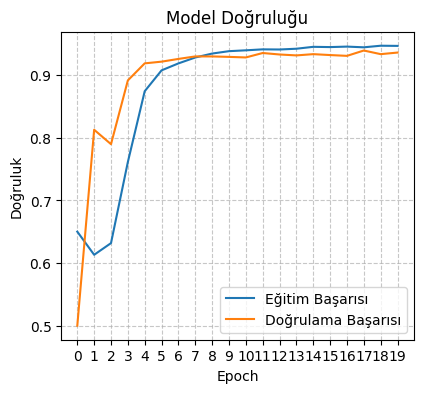

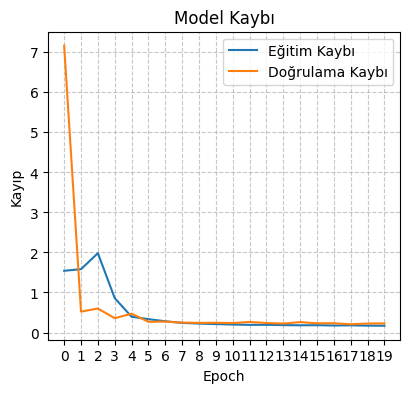

In [80]:
#model eğitim süreci incelemelerini yapalım 
# accuracy - doğruluk
plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Başarısı')
plt.plot(history.history['val_accuracy'], label='Doğrulama Başarısı')
plt.title('Model Doğruluğu')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.grid(True, linestyle='--', alpha=0.7) 
plt.xticks(np.arange(0, 20, step=1)) 
plt.legend()

# loss - kayıp
plt.figure(figsize=(10,4))
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.title('Model Kaybı')
plt.xlabel('Epoch')
plt.ylabel('Kayıp')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(np.arange(0, 20, step=1)) 
plt.legend()
plt.show()

In [81]:
"""model eğitim sürecinde güzel sonuç elde ettik model grafiğini incelediğimizde verimli geçtiğini görebiliyoruz 
  fakat grafiği incelediğimizde  3. epoch verisine kadar beklenenden farklı birkaç yönelim gördüm
  bu yönelimler 
  0 dan 1 değerlerinde doğrulama ve eğitim başarısı arasında zıt yönlü hareket 
  0 dan 1 e doğrulama başarısı değerindeki düşüş
  0 dan 2 ye katar eğitim kaybının artması

  araştırdığım kadarıyla bu anomalinin tek sorumlusu olmasa da model eğitim sürecinde bu oranları almamızdaki en büyük pay
  modelin diğer senaryoları daha iyi canlandırabilmesi adına kullandığımız fonksiyonlar olmalı. bu fonksiyonlar modelin
  eğitim sürecinde verilerin zoomlanmış -+0.1 , sağ sol 0.1 eğilmiş halini görmesi ve elindeki verilerden daha fazla
  çıkarımda bulunması modelin daha fazla tecrübesi olması için ekledim. fakat model eğitim sürecinde bunlarla
  karşılaştığında başlangıçta alışamıyor sonradan verilerin bu şekline de alışıyor peki bu grafiğe neden böyle yansıyor
    -*-*0 dan 1 değerlerinde doğrulama ve eğitim başarısı arasında zıt yönlü hareket*-*-
  çünkü modelin eğitim sürecinde bu suni veriler işlenir ve model bunlarla ilk karşılaşmada alışamaz dolayısıyla eğitim
  süreci ilk epoch larda verimsiz geçer eğitim başarısı düşer sonra yavaş yavaş alışır ve yavaş yavaş artmaya başlar 
  bu dediğim süreç 0 ile 2 arasında eğitim başarısı seyri üzerine
  peki doğrulama başarısı neden başta hızlı bir artış görüyor ve sonrasında belli bir miktarda düşüş görüyor
  eğitim sürecinde model gerçek verilerle ilk karşılaşmasında temel değerleri öğreniyor ve yüksek doğruluk
  gösteriyor fakat modelin eğitim sürecindeki suni verilerine alışmadığı için doğrulama başarısı belli bir oranda düşüyor


"""

'model eğitim sürecinde güzel sonuç elde ettik model grafiğini incelediğimizde verimli geçtiğini görebiliyoruz \n  fakat grafiği incelediğimizde  3. epoch verisine kadar beklenenden farklı birkaç yönelim gördüm\n  bu yönelimler \n  0 dan 1 değerlerinde doğrulama ve eğitim başarısı arasında zıt yönlü hareket \n  0 dan 1 e doğrulama başarısı değerindeki düşüş\n  0 dan 2 ye katar eğitim kaybının artması\n\n  araştırdığım kadarıyla bu anomalinin tek sorumlusu olmasa da model eğitim sürecinde bu oranları almamızdaki en büyük pay\n  modelin diğer senaryoları daha iyi canlandırabilmesi adına kullandığımız fonksiyonlar olmalı. bu fonksiyonlar modelin\n  eğitim sürecinde verilerin zoomlanmış -+0.1 , sağ sol 0.1 eğilmiş halini görmesi ve elindeki verilerden daha fazla\n  çıkarımda bulunması modelin daha fazla tecrübesi olması için ekledim. fakat model eğitim sürecinde bunlarla\n  karşılaştığında başlangıçta alışamıyor sonradan verilerin bu şekline de alışıyor peki bu grafiğe neden böyle yansıyor

In [83]:
model.save('sitma_tespit_modeli.keras')
